In [166]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

### A random function

In [10]:
def f(x):
    return x**2+3*x+3

Text(0.5, 1.0, 'Plot of f(x)')

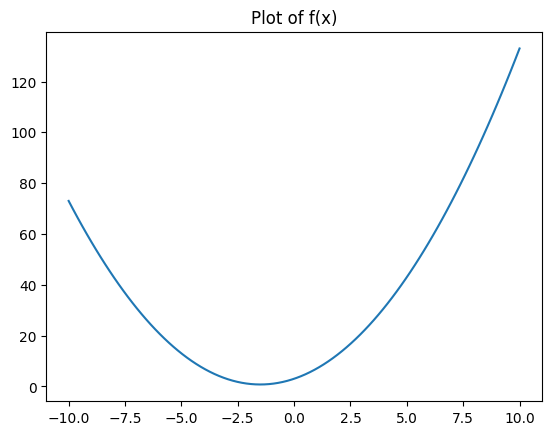

In [8]:
xs=np.linspace(-10, 10, 100)
ys=f(xs)
plt.plot(xs, ys, label='f(x) = x^2 + 3x + 3')
plt.title('Plot of f(x)')

### let's get it's derivative

In [13]:
def derivative(x):
    h=1e-10
    return (f(x+h)-f(x))/h

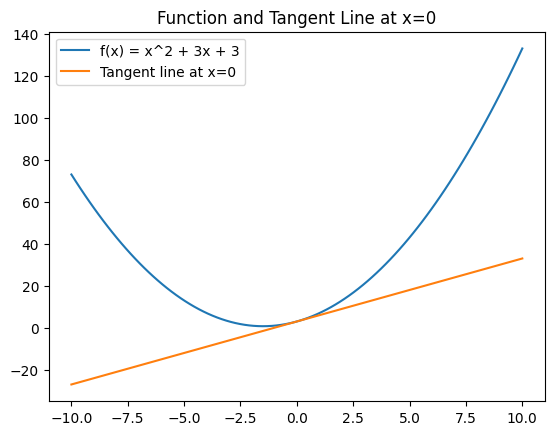

In [14]:
x0=0
df_dx=derivative(x0)
plt.plot(xs, ys, label='f(x) = x^2 + 3x + 3')  # plot the initial function
plt.plot(xs, f(x0) + df_dx * (xs - x0), label='Tangent line at x=0')  # plot the tangent line
plt.title('Function and Tangent Line at x=0')
plt.legend()
plt.show()

### now it's time for partial derivatives

In [ ]:
def func(x,y):
    """Function to compute the value of the sphere equation."""
    return x**2 + y**2  - 1
def grad(x,y):
    """Compute the gradient of the any 3 varible equation."""
    h=1e-10
    df_dx=( func(x+h,y) - func(x-h,y) ) / (2*h)
    df_dy=( func(x,y+h) - func(x,y-h) ) / (2*h)
    return np.array([df_dx, df_dy])

In [22]:
ys=func(xs,xs)

## Follow the tutorial

In [202]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        """ Initialize the Value object with data."""
        # This method is called when you create an object of the class
        # self.data is an attribute of the class
        # data is the input to the class
        # self.data is the data that you want to store in the object
        self.data=data
        self._prev=set(_children)
        # _children is a set of the previous values that were used to compute this value
        self._op=_op
        self.label=label # just for the graphviz to visualize the graph
        self.grad=0.0
        self._backward= lambda: None


    def __repr__(self):
        """ String representation of the Value object."""
        # This method is called when you use print() on the object
        return f"Value( data= {self.data})"
    def __add__(self,other):
        """ Add two Value objects."""
        # why add is required?
        # This method is called when you use + on the object because python don't know how to add two value objects
        other=other if isinstance(other,Value) else Value(other)
        out= Value(self.data + other.data,(self,other),'+')
        def _backward():
            """ _backward pass for addition to we used current grad to compute the gradient of the previous values."""
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward
        return out
    def __mul__ (self,other):
        """ Multiply two Value objects."""
        # This method is called when you use * on the object
        other=other if isinstance(other,Value) else Value(other)
        out= Value(self.data * other.data,(self,other),'*')
        def _backward():
            """ _backward pass for multiplication to we used current grad to compute the gradient of the previous values."""
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    def __rmul__(self,other):  #other*self
        return self*other
    def __radd__(self,other):  #other+self
        return self+other
    def __neg__(self):
        """ Negate the Value object."""
        return self*-1
    def __sub__(self,other):
        """ Subtract two Value objects."""
        return self+(-other)
    
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,), 'exp')
        def _backward():
            self.grad+=out.grad*out.data
        out._backward=_backward
        return out
    
    def __pow__(self,other):
        assert isinstance(other,(int,float)), "other should be int or float"
        out= Value(self.data**other,(self,), 'pow')
        def _backward():
            self.grad+=other*(self.data**(other-1))*out.grad
        out._backward=_backward
        return out
    
    def __truediv__(self,other):
        return self*(other**-1)
    def tanh(self):
        """ Compute the tanh of the Value object."""
        # This method is called when 
        # you use tanh on the object
        n=self.data
        t= (math.exp(n)-math.exp(-n))/(math.exp(n)+math.exp(-n));
        out= Value(t, (self,), 'tanh')
        def _backward():
            """ _backward pass for tanh to we used current grad to compute the gradient of the previous values."""
            self.grad+= (1-t*t)*out.grad
        out._backward=_backward
        return out
    def backward(self):
        """ Backward pass to compute the gradient of the Value object."""
        """ Implementing topological sort to compute the order or say flow to compute the gradient of each component ."""
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)    ## edges are from parent to child so the o is the overall parent and therefore it is appended last
        self.grad=1.0
        # # if compare with dsa we should reverse the list to get the topological order
        # print(topo)
        for node in reversed(topo):
            node._backward()

In [66]:
a=Value(2,label='a')
b=Value(3,label='b')
c=a+b
c.label='c'
print(c)  # Output: Value(5)
d=c*a
d.label='d'
print(d)  # Output: Value(10)
e=d+b
e.label='e'
f=Value(4,label='f')
L=e*f
L.label='L'
L

Value( data= 5)
Value( data= 10)


Value( data= 52)

In [67]:
print(d._prev)  # Output: {Value(2), Value(3)}
print(d._op)

{Value( data= 2), Value( data= 5)}
*


### code to visualize the graph from the tutorial directly

In [184]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

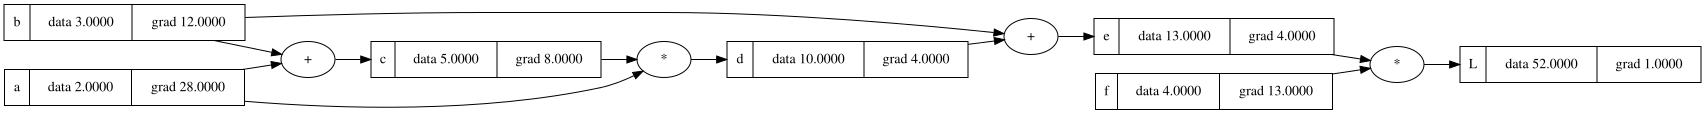

In [ ]:
# draw_dot(L)

In [ ]:
# L.grad=1.0
# e.grad=f.data    # dl/de=f
# f.grad=e.data    # dl/df=e

In [ ]:
# ## deriving dl/dd   crux of backpropagation
# ## dl/dd= dl/de * de/dd simple chain rule one affects the other
# # de/dd= 1
# # dd/db=1
# # Want:
# # dl/dd= dl/de * de/dd

# # Know:
# # dl/dd = 4*1


# # de/dd
# d.grad=4
# c.grad=d.grad*a.data
# a.grad=c.grad+d.grad*c.data
# b.grad=c.grad+e.grad            
# ## look at the graph this simple it is

In [ ]:
# def lol():
#     """ Compute the gradient of the function wrt a brute force ."""
#     h=1e-10
#     a=Value(2,label='a')
#     b=Value(3,label='b')
#     c=a+b
#     c.label='c'
#     print(c)  # Output: Value(5)
#     d=c*a
#     d.label='d'
#     print(d)  # Output: Value(10)
#     e=d+b
#     e.label='e'
#     f=Value(4,label='f')
#     L=e*f
#     L.label='L'
#     L1=L.data

#     a=Value(2,label='a')
#     b=Value(3,label='b')
#     c=a+b
#     c.label='c'
#     print(c)  # Output: Value(5)
#     d=c*a
#     d.label='d'
#     print(d)  # Output: Value(10)
#     e=d+b
#     e.data+=h
#     e.label='e'
#     f=Value(4,label='f')
#     L=e*f
#     L.label='L'
#     L2=L.data
#     print((L2-L1)/h);



In [ ]:
# lol()    # numerically verified the gradient of e is f

Value( data= 5)
Value( data= 10)
Value( data= 5)
Value( data= 10)
4.000000330961484


### lets work on a nueron now wohoo

In [ ]:
# inputs
x1=Value(2,label='x1')
x2=Value(0,label='x2')

# weights
w1=Value(-3,label='w1')
w2=Value(1,label='w2')

#bias
b=Value(6.8813735870195432,label='b')

# z= w1*x1 + w2*x2 + b
x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1w1x2w2'
n=x1w1x2w2+b;n.label='n'

## 
e=(2*n).exp();e.label='e'
# o= (e-1)/(e+1);o.label='o'
o=n.tanh() 

In [149]:
# ## it's crazy dude and easy too

# o.grad=1.0
# n.grad=1.0-o.data**2    ## derivative of tanh= 1-tanh^2
# b.grad=n.grad
# x1w1x2w2.grad=n.grad
# x1w1.grad=x1w1x2w2.grad
# x2w2.grad=x1w1x2w2.grad
# x2.grad=x2w2.grad*w2.data
# x1.grad=x1w1.grad*w1.data
# w1.grad=x1w1.grad*x1.data
# w2.grad=x2w2.grad*x2.data


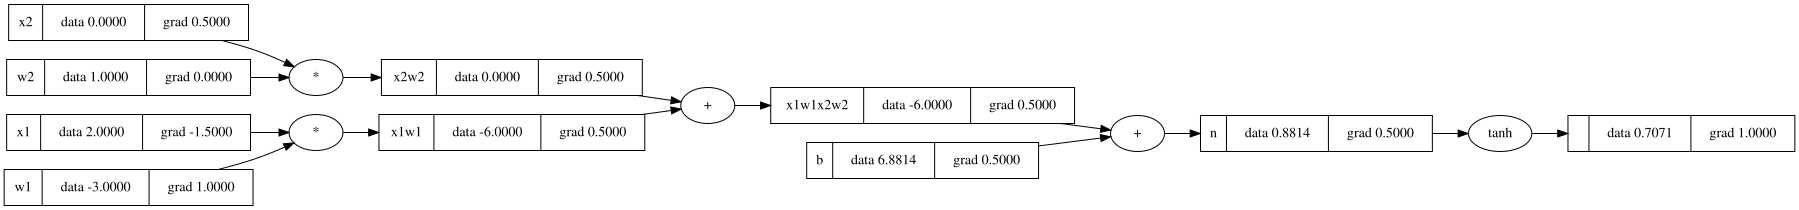

In [153]:
draw_dot(o)

In [151]:
# o.grad=1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()


In [152]:
o.backward()

In [158]:
e=(2*n).exp()
o=(e-1)/(e+1)

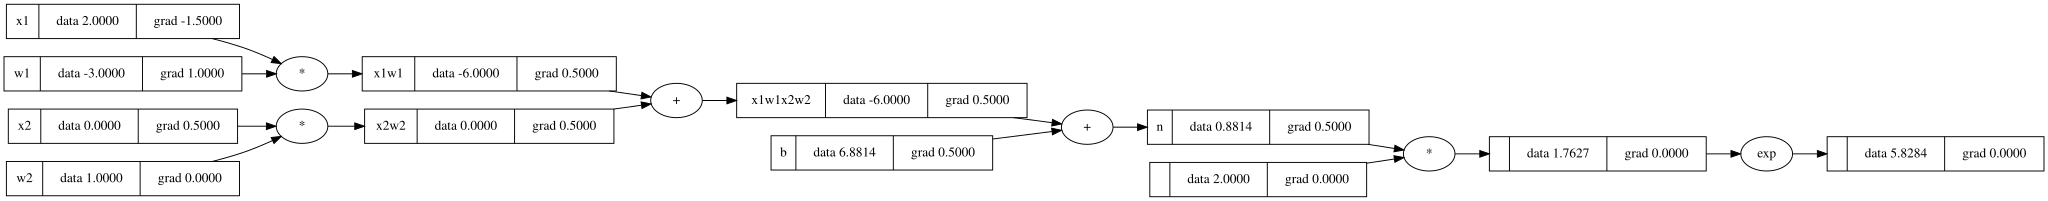

In [ ]:
draw_dot(e)
## same as o

### using torch very similar to our class 

In [160]:
import torch

In [163]:
x1=torch.tensor([2.0]).double();x1.requires_grad=True
x2=torch.tensor([0.0]).double();x2.requires_grad=True
w1=torch.tensor([-3.0]).double();w1.requires_grad=True
w2=torch.tensor([1.0]).double();w2.requires_grad=True
b=torch.tensor([6.8813735870195432]).double();b.requires_grad=True
n=w1*x1+w2*x2+b
o=torch.tanh(n)
print(o.data.item())
o.backward()

0.7071066904050358


In [164]:
print('-----')
print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())
print('b', b.grad.item())

-----
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0
b 0.5000001283844369


#### building nn

In [212]:
class Nueron:
    def __init__(self,nin):
        """ nin is number of nuerons in the layer"""
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    
    def __call__(self,x):
        ''' call is () operator in python'''
        ''' x is the input to the neuron'''
        act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)  # zip to make pairs 
        out=act.tanh()
        # print(list(zip(self.w,x)))
        return out
    def parameters(self):
        """ return the parameters of the neuron"""
        return self.w + [self.b]

    

In [ ]:
class Layer:
    def __init__(self, nin, nout):
        """Initialize a layer with nout neurons, each taking nin inputs."""
        # Create a list of neurons, each neuron takes nin inputs
        self.neurons = [Nueron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        """Forward pass: compute the output of all neurons in the layer for input x."""
        # Pass the input x to each neuron and collect their outputs in a list
        out = [n(x) for n in self.neurons]
        return out

    def parameters(self):
        """Return all parameters (weights and biases) of all neurons in the layer."""
        params = []
        for n in self.neurons:
            params += n.parameters()
        return params

class MLP:
    def __init__(self, nin, nouts):
        """
        Initialize a multi-layer perceptron.
        nin: number of inputs to the network
        nouts: list with the number of neurons in each layer
        """
        # sz is a list of layer sizes, starting with input size followed by each layer's output size
        sz = [nin] + nouts
        # Create a list of layers, each connecting sz[i] inputs to sz[i+1] outputs
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        """Forward pass: compute the output of the network for input x."""
        # Pass the input through each layer in sequence
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        """Return all parameters of all layers in the network."""
        # Collect parameters from each layer
        return [p for layer in self.layers for p in layer.parameters()]

In [214]:
x=[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
print(n(x))
n(x)

[Value( data= -0.25620437413957386)]


[Value( data= -0.25620437413957386)]

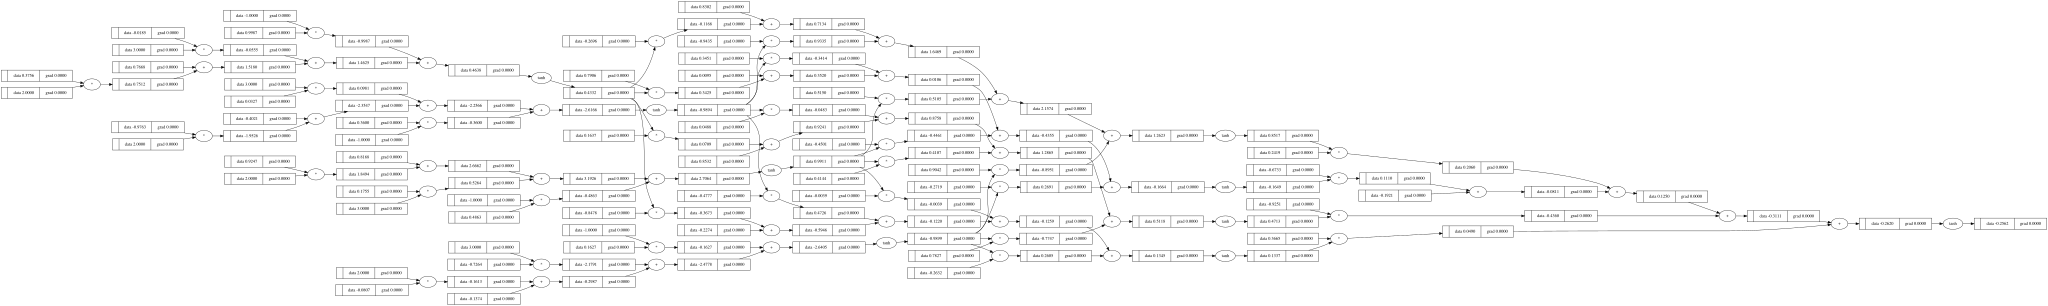

In [215]:
# the MLP returns a list of Value outputs, pick the first (and only) one
out = n(x)[0]
draw_dot(out)

In [218]:
n.parameters()

[Value( data= 0.37559188619929773),
 Value( data= -0.01848738169952302),
 Value( data= 0.9987219298868779),
 Value( data= 0.7668166453719054),
 Value( data= -0.9762923578797342),
 Value( data= 0.03270613409745571),
 Value( data= 0.3600411129468353),
 Value( data= -0.4021070180527391),
 Value( data= 0.9247135638163082),
 Value( data= 0.17547384011814704),
 Value( data= 0.4862616681476526),
 Value( data= 0.8167732824665084),
 Value( data= -0.08066168365533355),
 Value( data= -0.7263527065177515),
 Value( data= 0.16266487400793195),
 Value( data= -0.13740784013865182),
 Value( data= 0.7905520571928699),
 Value( data= 0.3450608244919362),
 Value( data= -0.4501264299660095),
 Value( data= -0.27187135990011124),
 Value( data= 0.009530452902190012),
 Value( data= -0.2695952636256902),
 Value( data= -0.9435117550197527),
 Value( data= 0.5150485173555075),
 Value( data= 0.9042175962085428),
 Value( data= 0.8301694756890734),
 Value( data= 0.16367276117644192),
 Value( data= 0.048805215475578034

In [219]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0,5,1,1],
    [1,1,-1]
]
ys=[1,-1,-1,1]
ypred=[n(x) for x in xs]
ypred

[[Value( data= -0.25620437413957386)],
 [Value( data= -0.745165362965146)],
 [Value( data= -0.865166686625673)],
 [Value( data= -0.08423998179162563)]]

In [220]:
loss= sum((yout[0]-ygt)**2 for ygt,yout in zip(ys,ypred))

In [221]:
loss.backward()


In [222]:
n.layers[0].neurons[0].w[0].grad

5.466922673958898

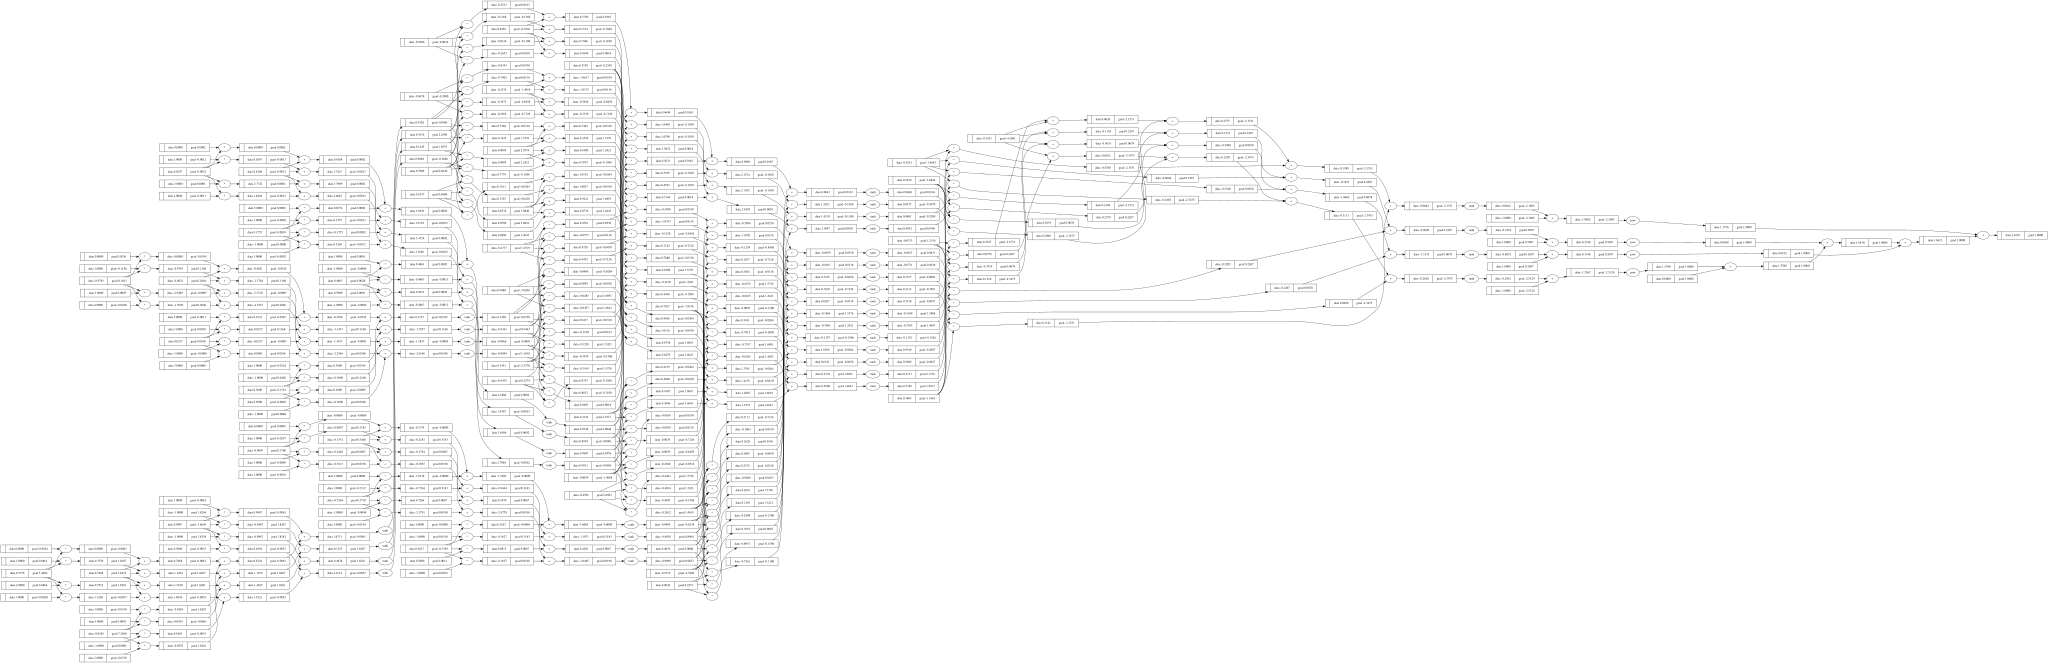

In [223]:
draw_dot(loss)

In [224]:
for epoch in range(100):
    loss= sum((yout[0]-ygt)**2 for ygt,yout in zip(ys,ypred))
    loss.backward()
    for p in n.parameters():
        p.data-=0.01*p.grad
        p.grad=0.0
    ypred=[n(x) for x in xs]
    print(epoch,loss.data)
    print(epoch,ypred)

0 2.8367464823510886
0 [[Value( data= 0.979552608778719)], [Value( data= 0.7513785048233905)], [Value( data= 0.9441198919129234)], [Value( data= 0.9762022993576823)]]
1 6.847913247652549
1 [[Value( data= 0.9764477392971552)], [Value( data= 0.6588342117197016)], [Value( data= 0.9282165684992489)], [Value( data= 0.9722368901148297)]]
2 6.471075576261453
2 [[Value( data= 0.9722155560408877)], [Value( data= 0.5369707623947476)], [Value( data= 0.9025870617164188)], [Value( data= 0.9667487723384965)]]
3 5.983994271334121
3 [[Value( data= 0.9664432760833163)], [Value( data= 0.38908114491242685)], [Value( data= 0.8594987479943785)], [Value( data= 0.9591532061560911)]]
4 5.390076535231228
4 [[Value( data= 0.9585490012889162)], [Value( data= 0.22620052545032765)], [Value( data= 0.7864567090733717)], [Value( data= 0.9486295199290555)]]
5 4.699352413524787
5 [[Value( data= 0.947627755651248)], [Value( data= 0.06447317075810703)], [Value( data= 0.6709345367492102)], [Value( data= 0.933928871048338)